In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-23 08:36:16--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.2’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.003s  

2025-10-23 08:36:17 (30.4 MB/s) - ‘course_lead_scoring.csv.2’ saved [80876/80876]



In [3]:
df = pd.read_csv('course_lead_scoring.csv')
df.columns = df.columns.str.lower()

In [5]:
df.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [6]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [7]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [9]:
categorical = list(df.dtypes[df.dtypes == 'object'].index)
numerical = []
for column in df.columns:
    if column not in categorical:
        numerical.append(column)
        
numerical
categorical

['lead_source', 'industry', 'employment_status', 'location']

In [10]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)

In [11]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)

df_full_train = df_full_train.reset_index()
df_train = df_train.reset_index()
df_val = df_val.reset_index()
df_test = df_test.reset_index()

In [14]:
from sklearn.metrics import roc_auc_score

numerical_features_auc = numerical.copy()
numerical_features_auc.remove('converted')

for feature in numerical_features_auc:
    if roc_auc_score(df['converted'],df[feature]) < 0.5: 
        print ('%s %.3f' % (feature, roc_auc_score(df['converted'],-df[feature])))
    else:
        print ('%s %.3f' % (feature, roc_auc_score(df['converted'],df[feature])))


number_of_courses_viewed 0.761
annual_income 0.543
interaction_count 0.722
lead_score 0.615


In [17]:
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse = False)

train_dict = df_train.to_dict(orient = 'records')
y_train = df_train.converted.values
del df_train['converted']
X_train = dv.fit_transform(train_dict)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver = 'liblinear', C = 1.0, max_iter = 1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
df_train

,index,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,462,events,manufacturing,2,95543.0,unemployed,europe,3,0.78
1,135,referral,NA,1,54924.0,student,south_america,6,0.39
2,117,organic_search,healthcare,2,77352.0,unemployed,europe,2,0.22
3,1051,paid_ads,other,2,34600.0,employed,south_america,2,0.31
4,945,paid_ads,education,0,43615.0,unemployed,south_america,2,0.01
...,...,...,...,...,...,...,...,...,...
871,39,NA,other,5,67314.0,NA,europe,2,0.87
872,1261,events,education,6,63996.0,NA,australia,4,0.92
873,595,organic_search,finance,1,73702.0,unemployed,north_america,2,0.55
874,1329,events,technology,1,93341.0,student,middle_east,4,0.99


In [39]:
val_dict = df_val.to_dict(orient = 'records')

X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)




0.8166522864538395

In [40]:
round(roc_auc_score(y_val, y_pred),2)

0.82

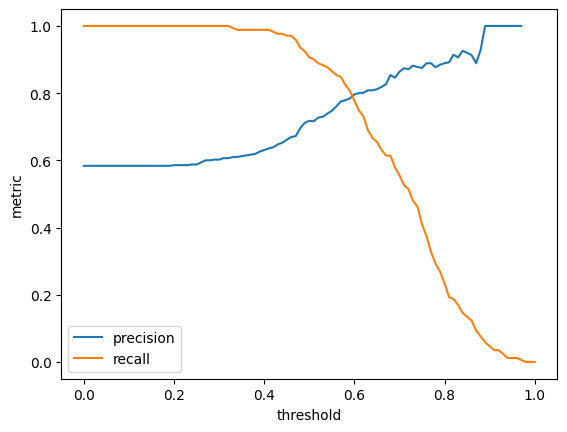

In [41]:
scores = []
thresholds = np.linspace(0,1,101)

for t in thresholds: 
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred <= t)
    
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    p = tp / (tp + fp)
    r = tp / (tp + fn)
    
    scores.append((t, p, r))
    
columns = ['threshold', 'precision', 'recall']
df_scores = pd.DataFrame(scores, columns = columns)

plt.plot(df_scores.threshold,df_scores.precision, label = 'precision')
plt.plot(df_scores.threshold,df_scores.recall, label = 'recall')
plt.xlabel('threshold')
plt.ylabel('metric')
plt.legend()

In [42]:
scores = []
thresholds = np.linspace(0,1,101)

for t in thresholds: 
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred <= t)
    
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    p = tp / (tp + fp)
    r = tp / (tp + fn)
    f1_score = 2 * ((p * r) / (p + r))
    
    scores.append((t, p, r, f1_score))

columns = ['threshold', 'precision', 'recall', 'f1_score']
df_scores = pd.DataFrame(scores, columns = columns)

max_f1_score = df_scores['f1_score'].max()
print(max_f1_score)
df_scores[df_scores['f1_score'] == max_f1_score].threshold

0.8100558659217877


57    0.57
Name: threshold, dtype: float64

In [43]:
def train(df_train, y_train, C=1.0):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver = 'liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [44]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred


In [46]:
from sklearn.model_selection import KFold 

kfold = KFold(n_splits = 5, shuffle = True, random_state = 1)
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = df_train.converted.values
    y_val = df_val.converted.values
    
    dv, model = train(df_train, y_train, C = 1)
    y_pred = predict(df_val, dv, model)
    
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
    
std = np.array(scores).std()
std


np.float64(0.05167430887601433)

In [51]:
def train(df_train, y_train, C=1.0):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver = 'liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [52]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred


In [57]:
n_splits = 5

for C in [0.000001, 0.001, 1]:
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        # the k-fold split uses index to shuffle the data
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        
        # y values come from dataset
        y_train = df_train.converted.values
        y_val = df_val.converted.values
        
        # training and predicting
        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)
        
        # AUC
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    
    print('C= %s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))


C= 1e-06 0.551 +- 0.024
C= 0.001 0.906 +- 0.024
C= 1 0.928 +- 0.052
